In [1]:
!pip install pandas numpy matplotlib seaborn

In [3]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
# Load datasets

trader_df = pd.read_csv("/content/historical_data.csv")
sentiment_df = pd.read_csv("/content/fear_greed_index.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [5]:
#Dataset Information

print("Trader Dataset")
display(trader_df.head())

print("\nFear & Greed Dataset")
display(sentiment_df.head())

Trader Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Fear & Greed Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
print("Trader Dataset Info")
print(trader_df.info())

print("\nFear & Greed Dataset Info")
print(sentiment_df.info())

Trader Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtype

In [7]:
#Check Missing Values
print("Missing Values in Trader Dataset")
print(trader_df.isnull().sum())

print("\nMissing Values in Sentiment Dataset")
print(sentiment_df.isnull().sum())

Missing Values in Trader Dataset
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing Values in Sentiment Dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [8]:
#Check Duplicate Rows

print("Duplicate Rows in Trader Dataset:", trader_df.duplicated().sum())

print("Duplicate Rows in Sentiment Dataset:", sentiment_df.duplicated().sum())

Duplicate Rows in Trader Dataset: 0
Duplicate Rows in Sentiment Dataset: 0


In [12]:
# Convert datetime columns

# Convert date columns

trader_df['Timestamp IST'] = pd.to_datetime(
    trader_df['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

print("Date columns converted successfully")



Date columns converted successfully


In [13]:
# Create common date column for merging

trader_df['Date'] = trader_df['Timestamp IST'].dt.date

sentiment_df['Date'] = sentiment_df['date'].dt.date

display(trader_df[['Timestamp IST', 'Date']].head())

,Timestamp IST,Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [14]:
# Merge datasets

merged_df = pd.merge(
    trader_df,
    sentiment_df,
    on='Date',
    how='left'
)

print("Datasets merged successfully")

display(merged_df.head())

Datasets merged successfully


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


In [15]:
print("Merged Dataset Shape:", merged_df.shape)

Merged Dataset Shape: (211224, 21)


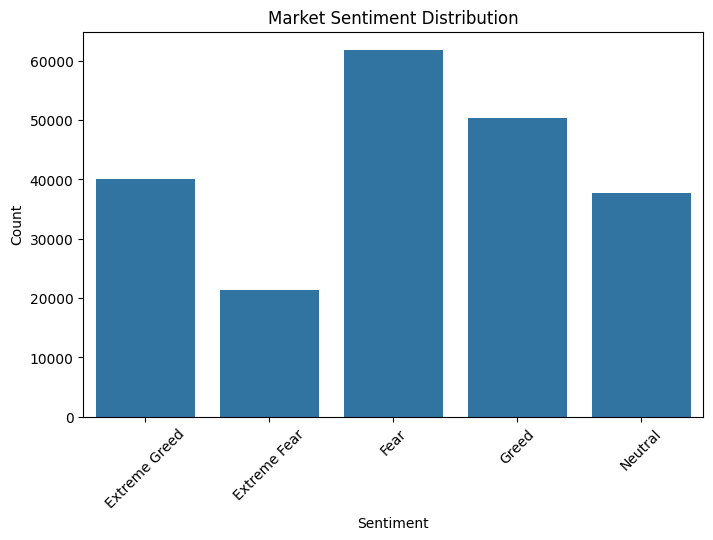

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='classification',
    data=merged_df
)

plt.title("Market Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

Average PnL
classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

Total PnL
classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


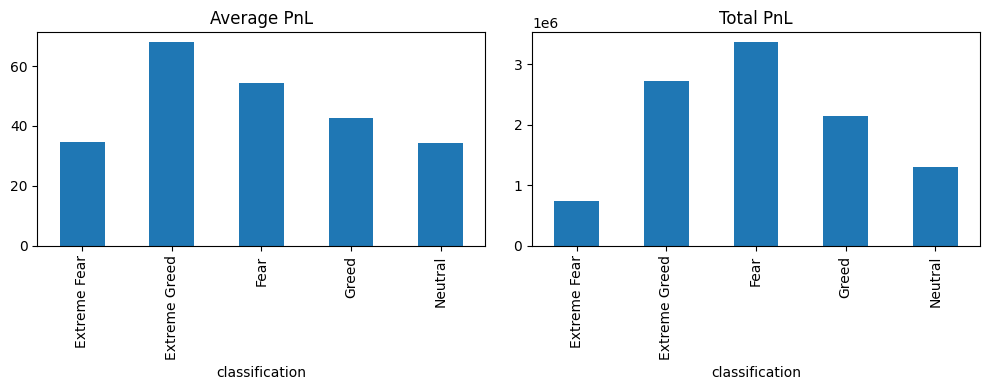

In [18]:
# Average and total profit by sentiment

avg_pnl = merged_df.groupby('classification')['Closed PnL'].mean()
total_pnl = merged_df.groupby('classification')['Closed PnL'].sum()

print("Average PnL")
print(avg_pnl)

print("\nTotal PnL")
print(total_pnl)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
avg_pnl.plot(kind='bar')
plt.title("Average PnL")

plt.subplot(1,2,2)
total_pnl.plot(kind='bar')
plt.title("Total PnL")

plt.tight_layout()
plt.show()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


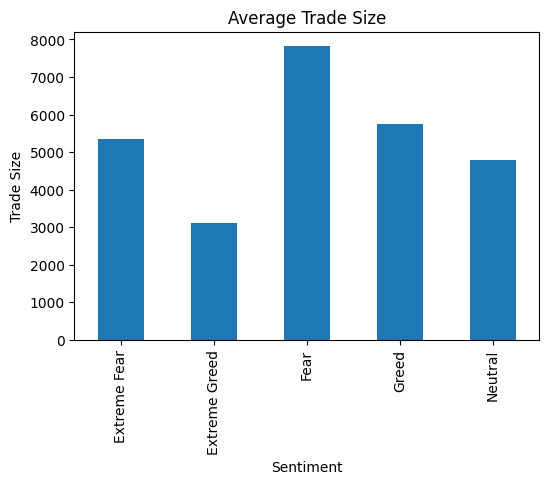

In [19]:
# Trade size analysis

avg_trade_size = merged_df.groupby('classification')['Size USD'].mean()

print(avg_trade_size)

plt.figure(figsize=(6,4))

avg_trade_size.plot(kind='bar')

plt.title("Average Trade Size")
plt.xlabel("Sentiment")
plt.ylabel("Trade Size")

plt.show()

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64


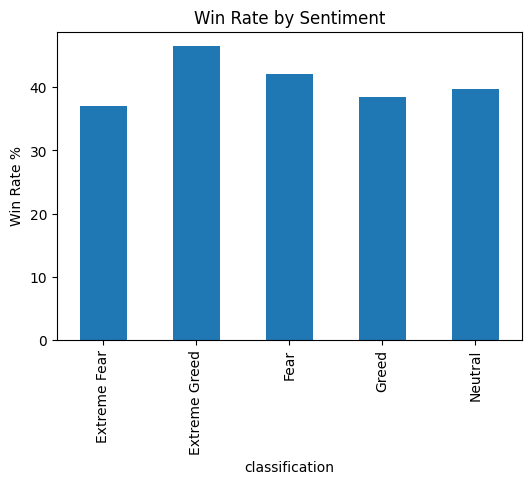

In [20]:
# Win rate analysis

merged_df['win'] = merged_df['Closed PnL'] > 0

win_rate = merged_df.groupby('classification')['win'].mean() * 100

print(win_rate)

plt.figure(figsize=(6,4))

win_rate.plot(kind='bar')

plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate %")

plt.show()

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64


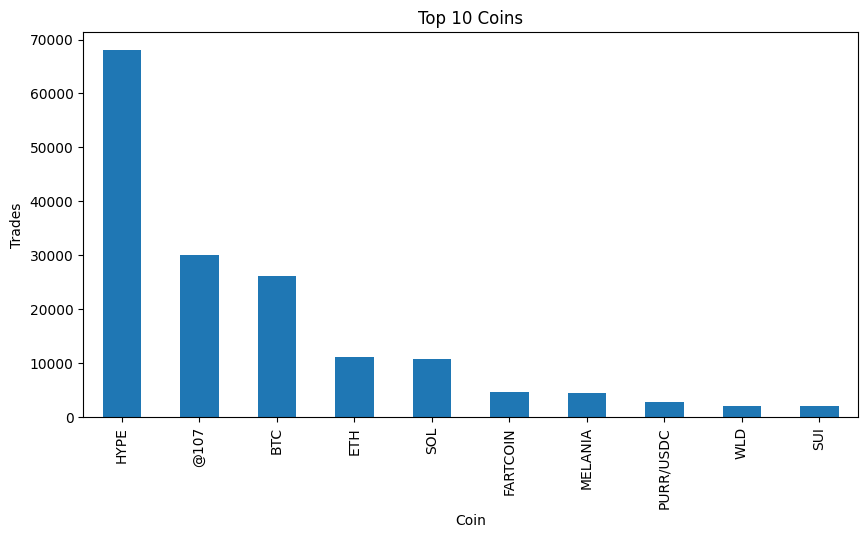

In [21]:
# Top traded coins

top_coins = merged_df['Coin'].value_counts().head(10)

print(top_coins)

plt.figure(figsize=(10,5))

top_coins.plot(kind='bar')

plt.title("Top 10 Coins")
plt.xlabel("Coin")
plt.ylabel("Trades")

plt.show()

Top Traders
Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

Top Coins
Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64


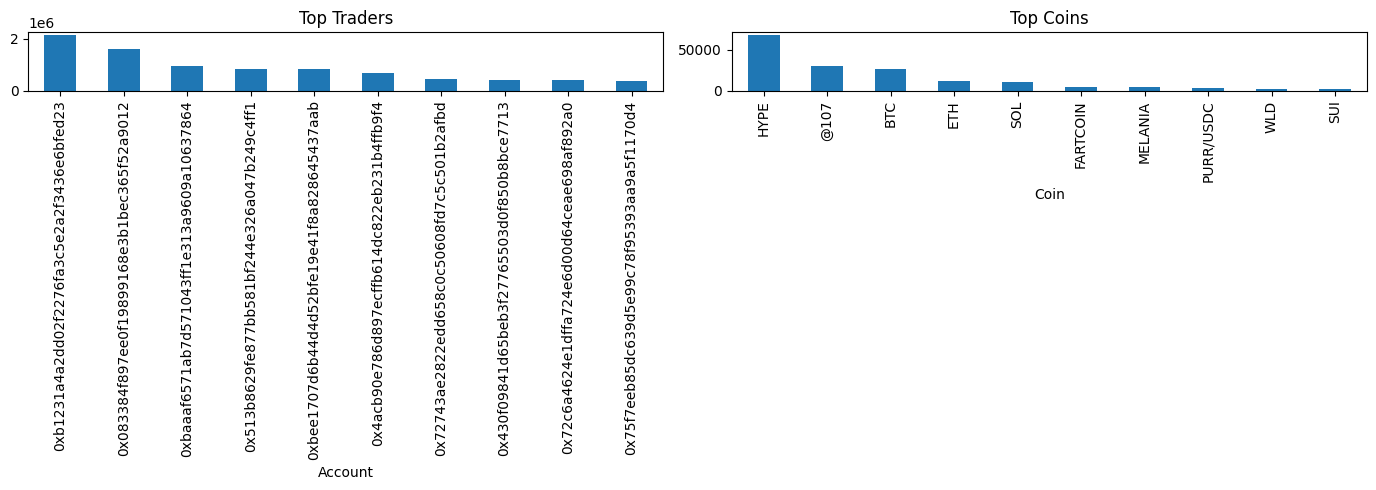

In [22]:
# Top traders and top coins analysis

top_traders = merged_df.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)

top_coins = merged_df['Coin'].value_counts().head(10)

print("Top Traders")
print(top_traders)

print("\nTop Coins")
print(top_coins)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
top_traders.plot(kind='bar')
plt.title("Top Traders")

plt.subplot(1,2,2)
top_coins.plot(kind='bar')
plt.title("Top Coins")

plt.tight_layout()
plt.show()

                 Closed PnL  Execution Price  Size USD       Fee
Closed PnL         1.000000        -0.006505  0.123589  0.084020
Execution Price   -0.006505         1.000000  0.189855  0.225265
Size USD           0.123589         0.189855  1.000000  0.745939
Fee                0.084020         0.225265  0.745939  1.000000


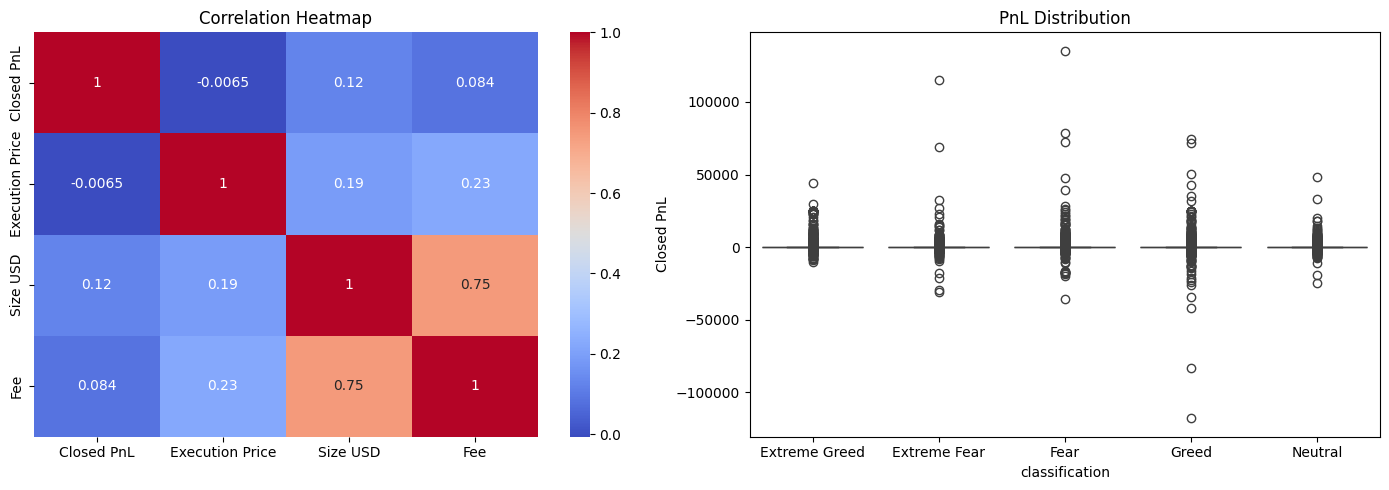

In [23]:
# Correlation and PnL distribution

correlation = merged_df[
    ['Closed PnL', 'Execution Price', 'Size USD', 'Fee']
].corr()

print(correlation)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.subplot(1,2,2)

sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged_df
)

plt.title("PnL Distribution")

plt.tight_layout()
plt.show()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64


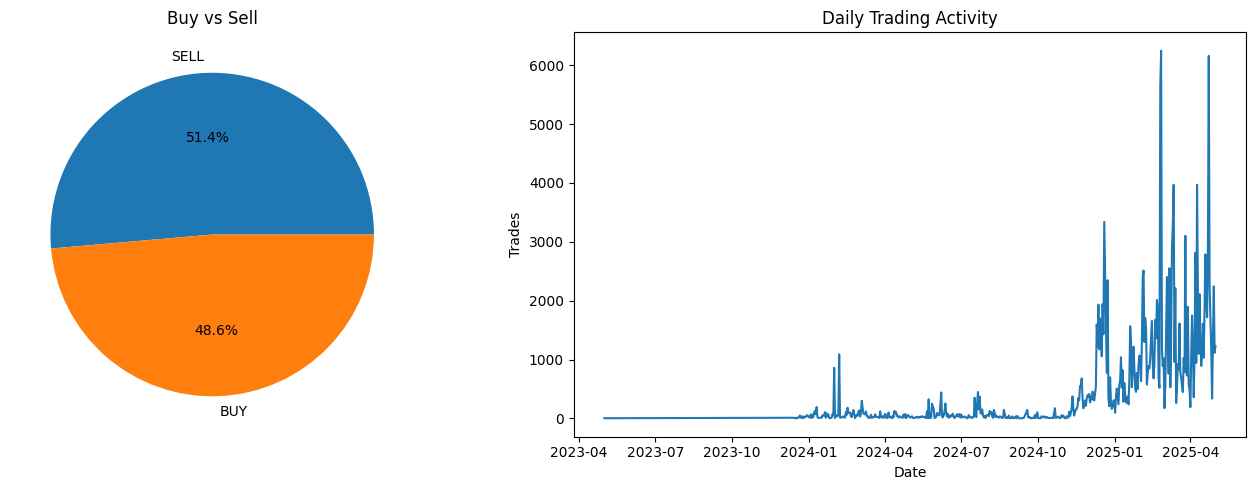

In [24]:
# Buy sell analysis and trading activity

side_analysis = merged_df['Side'].value_counts()

print(side_analysis)

daily_trades = merged_df.groupby('Date').size()

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

side_analysis.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Buy vs Sell")
plt.ylabel('')

plt.subplot(1,2,2)

daily_trades.plot()

plt.title("Daily Trading Activity")
plt.xlabel("Date")
plt.ylabel("Trades")

plt.tight_layout()
plt.show()

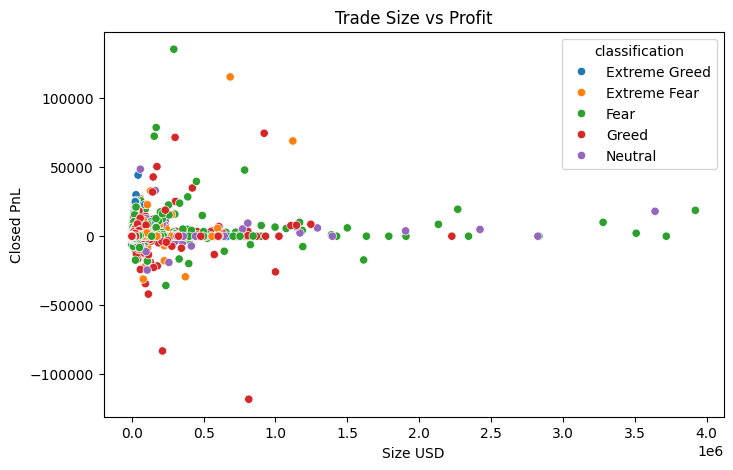

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,timestamp,value,date
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,2.112180e+05,211218.000000,211218
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915009792,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,1.738301e+09,51.649656,2025-01-30 23:58:26.735221248
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,1.682919e+09,10.000000,2023-05-01 00:00:00
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,1.735623e+09,33.000000,2024-12-31 00:00:00
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,1.740375e+09,49.000000,2025-02-24 00:00:00
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,1.743572e+09,72.000000,2025-04-02 00:00:00
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,1.746077e+09,94.000000,2025-05-01 00:00:00
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,8.029302e+06,21.012784,NaN


In [25]:
# Trade size vs profit and summary

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Size USD',
    y='Closed PnL',
    hue='classification',
    data=merged_df
)

plt.title("Trade Size vs Profit")

plt.show()

summary = merged_df.describe()

display(summary)

In [26]:
# Final insights and conclusion

print("Key Insights")

print("\n1. Market sentiment affects trader decisions.")

print("\n2. Greed periods show higher activity and risk.")

print("\n3. Fear periods show cautious trading behavior.")

print("\n4. Trade size impacts profitability.")

print("\n5. Emotional sentiment influences market trends.")

print("""
Conclusion

Trader behavior changes significantly
during Fear and Greed market conditions.

Trading activity, profit, and risk exposure
are strongly influenced by sentiment.

These findings help improve trading strategies
and decision making.
""")

Key Insights

1. Market sentiment affects trader decisions.

2. Greed periods show higher activity and risk.

3. Fear periods show cautious trading behavior.

4. Trade size impacts profitability.

5. Emotional sentiment influences market trends.

Conclusion

Trader behavior changes significantly
during Fear and Greed market conditions.

Trading activity, profit, and risk exposure
are strongly influenced by sentiment.

These findings help improve trading strategies
and decision making.



In [27]:
# Save final dataset

merged_df.to_csv(
    "final_merged_analysis.csv",
    index=False
)

print("Dataset saved successfully")

Dataset saved successfully


In [28]:
print(merged_df.head(5))

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0